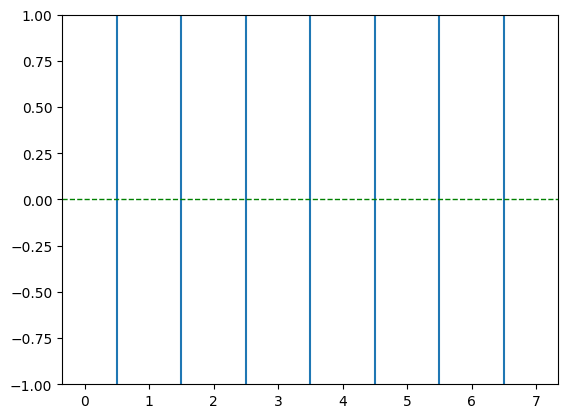

crude eigenvalues from shooting		 [0.5  1.49 2.5  3.5  4.5  5.5  6.5 ]
actual eigen values			 [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]
eigen values using bisect		 [0.5000000052896211, 1.4999999980986474, 2.5000000216081393, 3.5000000026353524, 4.5000000066633215, 5.500000013298995, 6.500000011750671]


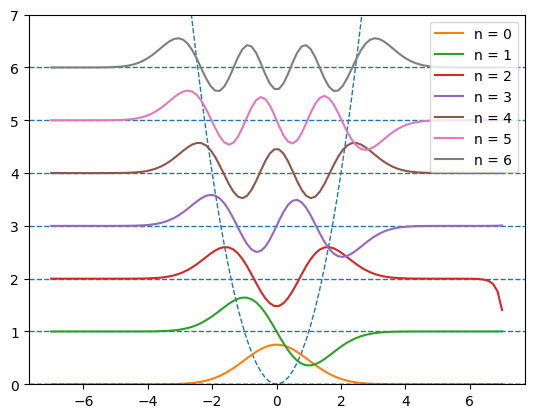

In [1]:
#TISE for harmonic oscillator


# let m*omega/h_cross=1 , V=1/2*m*omega**2*x**2,
# E=(n+1/2)*h_cross*omega, Cepsilon=E/(h_cross*omega)


import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint,simps
from scipy.optimize import bisect
from scipy import constants as const


a=7
V = lambda x : x**2
E_actual = lambda n: n+.5


def f(u,x,E):
    y,z=u
    f1,f2=z,(V(x)-2*E)*y
    return[f1,f2]


def shoot(E):
    sol=odeint(f,u,x,args=(E,)) # args takes tuple as arguments
    return sol[:,0][-1]


h=.01
b=7    # number of eigen orders
energies=np.arange(0,b,h)
x=np.linspace(-a,a,int(1/h))
u=[0,0.001]  # guess value doesn't matter


eigenvalues=[]
hits=np.zeros(energies.shape)
for i,E in enumerate(energies):
    hits[i]=shoot(E)


zero_cross_indices=np.where(np.diff(np.signbit(hits)))[0]
eigenvalues=zero_cross_indices*h


eigenvalues_actual=[E_actual(n) for n in range(len(eigenvalues))]


plt.plot(energies,hits)
plt.axhline(c='g',lw=1,ls='--')
plt.ylim(-1,1)
plt.show()
print('crude eigenvalues from shooting\t\t',eigenvalues)
print('actual eigen values\t\t\t',eigenvalues_actual)


eigen_bisect=[]
for i in eigenvalues:
    eigen_bisect.append(bisect(shoot,i-.1,i+.1))
print('eigen values using bisect\t\t',eigen_bisect)


plt.plot(x,V(x),ls="--",lw=1)
for i,eigen in enumerate(eigen_bisect):
    sol=odeint(f,u,x,args=(eigen,))
    psi=sol[:,0]
    psi=psi/np.sqrt(simps(psi**2,x))
    plt.axhline(i,ls='--',lw=1)
    plt.ylim((0,b))
    plt.plot(x,i+psi,label='n = ' + str(i) )
plt.axhline(lw=1,c='black',ls='--')
plt.legend()
plt.show()
